## 一元线性回归

本例中将用线性回归算法来寻求对于某地房价与面积的关系，属于一个非常经典的练习
```
数据在同名目录下的“房价预测.csv”中
```

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

### 1.数据的读取，处理与分类（训练集与测试集）

In [26]:
df = pd.read_csv('房价预测.csv', encoding = 'utf-8')
squares = df['房屋面积_平方米'].apply(lambda x: np.array(x, dtype = np.float32)).values
prices = df['成交价格_万元'].apply(lambda x: np.array(x, dtype = np.float32)).values

# test_size 为测试集占比，random_state 为打乱数据集时使用的种子，设定固定的种子方便结果的复现
X_train, X_test, y_train, y_test = train_test_split(squares, prices, test_size = 0.2, random_state = 42)

### 2.绘制数据集散点图以观察是否呈现线性关系

<function matplotlib.pyplot.show(close=None, block=None)>

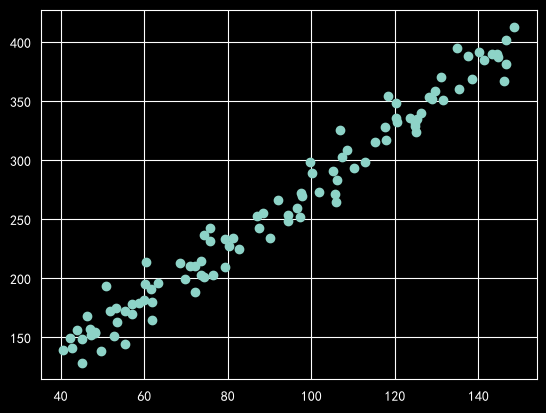

In [38]:
fig, ax = plt.subplots()
ax.scatter(squares, prices)
plt.show

### 3.进行模型训练并得出评价指标

In [58]:
#模型训练
model = LinearRegression()
model.fit(X_train.reshape(-1, 1), y_train)

#对于测试集的预测效果
y_hat = model.predict(X_test.reshape(-1, 1))
mse = mean_squared_error(y_test, y_hat)
rmse = np.sqrt(mean_squared_error(y_test, y_hat))
r2 = r2_score(y_test, y_hat)
print(f"系数为{model.coef_:.2f}, 截距为{model.intercept_}")
print(f'模型平均误差大约为：{rmse:.4f}, 线性化程度为：{r2:.4f}')

[2.44525841] 34.33336265900414
模型平均误差大约为：12.1291, 线性化程度为：0.9792


### 4.绘图以直观查看训练效果

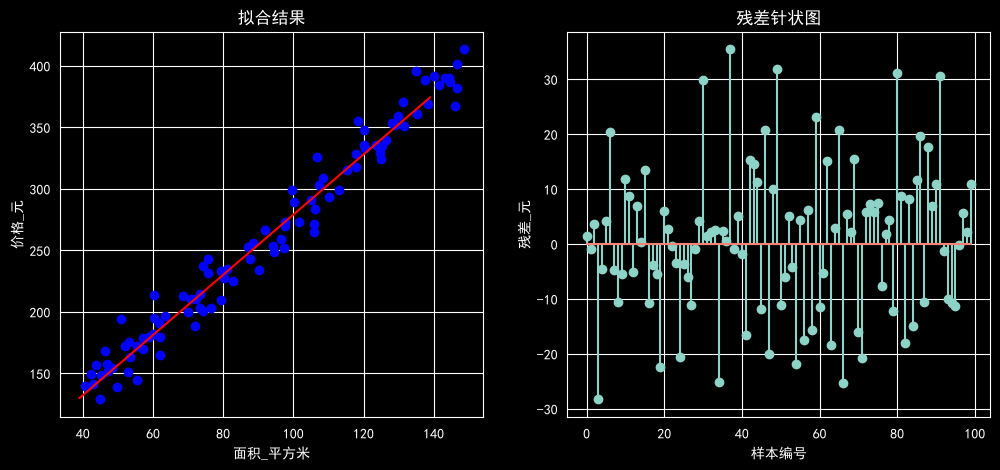

In [57]:
#绘制拟合图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))
ax1.scatter(squares, prices, color = 'blue')
X = range(int(min(squares)) - 1, int(max(squares)) + 1, 100)
X = np.array(X).reshape(-1, 1)
y = model.predict(X)
ax1.plot(X, y, color = 'red')
ax1.set_xlabel('面积_平方米')
ax1.set_ylabel('价格_万元')
ax1.set_title('拟合结果')

#绘制残差图（针状图）
prices_hat = model.predict(squares.reshape(-1, 1))
residuals = prices - prices_hat
residuals = np.array(residuals)
ax2.stem(residuals)
ax2.set_xlabel('样本编号')
ax2.set_ylabel('残差_万元')
ax2.set_title('残差针状图')

plt.show()